<a href="https://colab.research.google.com/github/jhonquimi-png/Aprendizaje_Automatico/blob/main/S2_Modelos_Supervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos Supervisados: Clasificación y Regresión
Dataset: Rendimiento académico de los estudiantes
Curso: Aprendizaje Automático — MIAR0525
Semana 2: Continuación del pipeline — Fase de Modelado


In [24]:
# ── 0.1 Importaciones ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Configuración visual
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(' Librerías importadas.')


 Librerías importadas.


In [42]:
!git config --global user.email "jhon.quimi@uees.edu.ec"
!git config --global user.name "jhonquimi-png"

In [65]:
# ── 0.2 Carga del dataset ──────────────────────────────────────────────────────
url_github = 'https://raw.githubusercontent.com/jhonquimi-png/Aprendizaje_Automatico/refs/heads/main/student_performance.csv?token=GHSAT0AAAAAAD4HOH4LR3P2LFHQSH724ZOW2PZKFJQ'
df1 = pd.read_csv(url_github, low_memory=False)
print(f'Dataset cargado: {df1.shape[0]:,} filas × {df1.shape[1]} columnas')

Dataset cargado: 500 filas × 11 columnas


In [66]:
df = df1.copy()
print(df)

    student_id  gender  age  study_hours_per_week  attendance_rate  \
0      STU0001    Male   15                    25          63.8000   
1      STU0002  Female   15                     2          54.7000   
2      STU0003  Female   19                    10          90.5000   
3      STU0004    Male   16                    26          66.8000   
4      STU0005  Female   15                    25          73.0000   
..         ...     ...  ...                   ...              ...   
495    STU0496  Female   19                     6          78.3000   
496    STU0497  Female   16                    27          61.1000   
497    STU0498  Female   18                    16          72.3000   
498    STU0499    Male   17                    29          91.3000   
499    STU0500    Male   15                    29          75.4000   

    parent_education internet_access extracurricular  previous_score  \
0           Bachelor             Yes             Yes              41   
1           Bac

**Análisis exploratorio de datos (EDA)**

**Describir variables y clases.**

Acerca del conjunto de datos
Creé este conjunto de datos para practicar la clasificación y regresión mediante aprendizaje automático. Contiene 500 registros de estudiantes con sus hábitos de estudio, datos demográficos y resultados de exámenes.

Las columnas incluyen información como horas de estudio semanales, tasa de asistencia, nivel educativo de los padres, calificaciones anteriores y calificaciones finales. La variable objetivo puede utilizarse final_scorepara regresión o passedclasificación (aprobar = puntuación >= 50).

Descripción de variables y clases

*   student_id:Identificador único de estudiante (STU0001-STU0500)
*   gender: Género del estudiante (Masculino/Femenino)
*   age: Edad del estudiante en años
*   study_hours_per_week: Horas de estudio semanales autoinformadas
*   attendance_rate: Porcentaje de asistencia a clase (0-100)
*   parent_education: Nivel educativo más alto de los padres
*   internet_access: Si el estudiante tiene internet en casa (Sí/No)
*   extracurricular: ¿El estudiante participa en actividades extracurriculares? (Sí/No)
*   previous_score: Puntuación del trimestre anterior (0-100)
*   final_score: Puntuación del examen final (0-100)
*   passed: aprueba o no el estudiante

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB
None
           age  study_hours_per_week  attendance_rate  previous_score  \
count 500.0000              500.0000         500.0000        500.0000   
mean   16.9780    

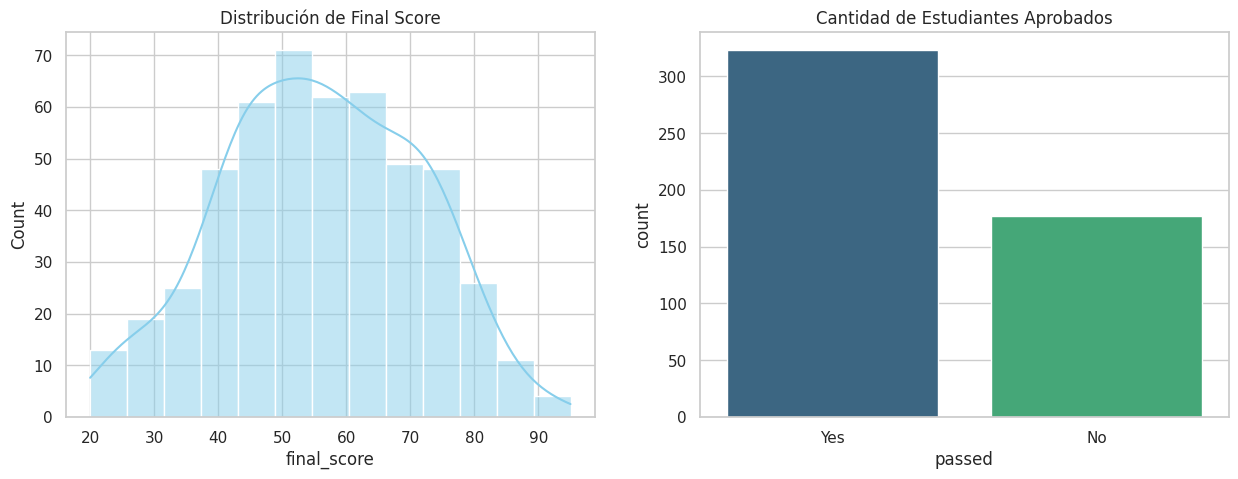

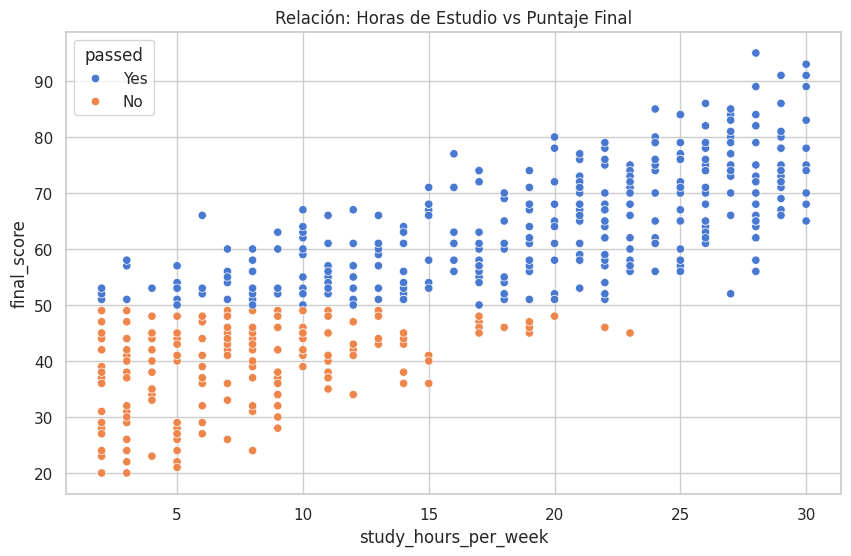

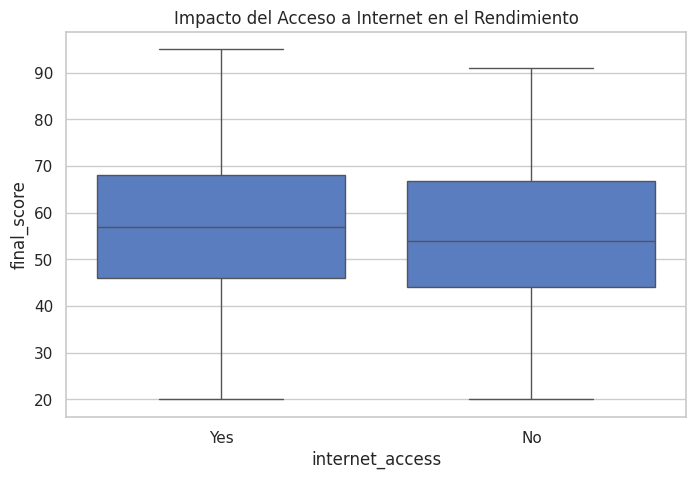

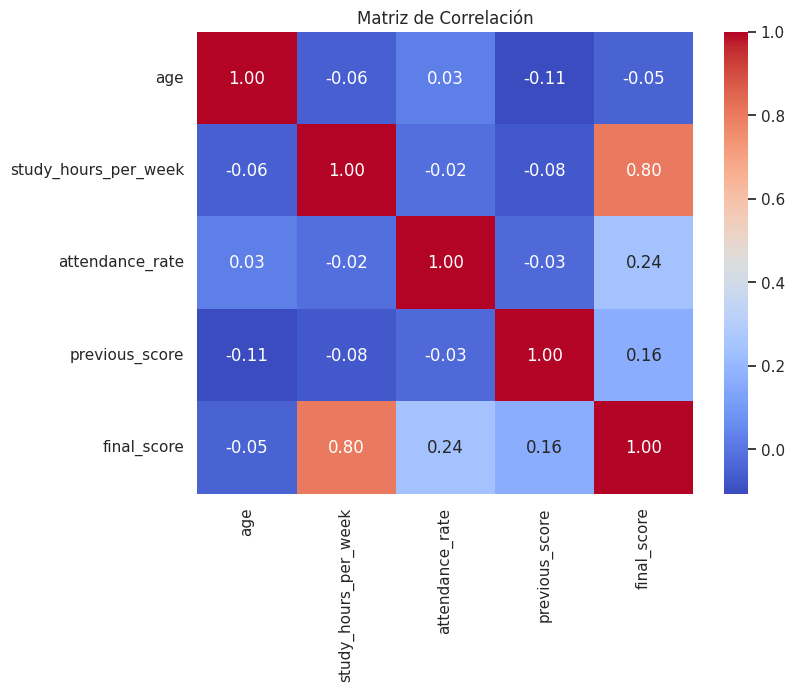

In [67]:

# Inspección Inicial y Limpieza
print(df.info())
print(df.describe())

# Manejo de valores nulos en parent_education (imputación por la moda o 'Unknown')
df['parent_education'] = df['parent_education'].fillna('Unknown')

#  Análisis Univariante (Distribuciones)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del puntaje final
sns.histplot(df['final_score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Final Score')

# Conteo de aprobados vs reprobados
sns.countplot(x='passed', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Cantidad de Estudiantes Aprobados')
plt.show()

# Análisis Bivariante (Relaciones)
plt.figure(figsize=(10, 6))

# ¿Más horas de estudio significan mejor nota?
sns.scatterplot(x='study_hours_per_week', y='final_score', hue='passed', data=df)
plt.title('Relación: Horas de Estudio vs Puntaje Final')
plt.show()

# Impacto del acceso a internet en el puntaje
plt.figure(figsize=(8, 5))
sns.boxplot(x='internet_access', y='final_score', data=df)
plt.title('Impacto del Acceso a Internet en el Rendimiento')
plt.show()

# Matriz de Correlación (Solo variables numéricas)
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [68]:
# Transformación de variables previo al modelamiento ──────────────────────────
df['passed_f'] = df['passed'].map({'Yes': 1, 'No': 0})
df['internet_access_f'] = df['internet_access'].map({'Yes': 1, 'No': 0})
df['extracurricularf_'] = df['extracurricular'].map({'Yes': 1, 'No': 0})
df['gender_f'] = df['gender'].map({'Female': 1, 'Male': 0})
print(df)

    student_id  gender  age  study_hours_per_week  attendance_rate  \
0      STU0001    Male   15                    25          63.8000   
1      STU0002  Female   15                     2          54.7000   
2      STU0003  Female   19                    10          90.5000   
3      STU0004    Male   16                    26          66.8000   
4      STU0005  Female   15                    25          73.0000   
..         ...     ...  ...                   ...              ...   
495    STU0496  Female   19                     6          78.3000   
496    STU0497  Female   16                    27          61.1000   
497    STU0498  Female   18                    16          72.3000   
498    STU0499    Male   17                    29          91.3000   
499    STU0500    Male   15                    29          75.4000   

    parent_education internet_access extracurricular  previous_score  \
0           Bachelor             Yes             Yes              41   
1           Bac

In [70]:
# ── Definición de features y variable objetivo ────────────────────────────

features_clf = ['age', 'study_hours_per_week', 'attendance_rate', 'previous_score',
                'final_score', 'internet_access_f', 'extracurricularf_',
                'gender_f']

# Problema A — Clasificación: ¿El estudiante pasó el curso?
X_clf = df[features_clf].copy()
y_clf = df['passed_f'].copy()

# Problema B — Regresión: ¿Cuál es la puntuación final del estudiante?
features_reg = ['age', 'study_hours_per_week', 'attendance_rate', 'previous_score',
                 'internet_access_f', 'extracurricularf_', 'gender_f']
X_reg = df[features_reg].copy()
y_reg = df['final_score'].copy()

# División train/test (80/20 con estratificación en clasificación)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42)

# Escalado (fit SOLO en train — evitar data leakage)
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(' Datasets listos para modelado')
print(f'   Clasificación — Train: {X_train_c_sc.shape}  |  Test: {X_test_c_sc.shape}')
print(f'   Regresión     — Train: {X_train_r_sc.shape}  |  Test: {X_test_r_sc.shape}')
print(f'   Balance clases (train): {y_train_c.mean()*100:.1f}% ')

 Datasets listos para modelado
   Clasificación — Train: (400, 8)  |  Test: (100, 8)
   Regresión     — Train: (400, 7)  |  Test: (100, 7)
   Balance clases (train): 64.5% 


---
## 1. Fundamentos: ¿Clasificación o Regresión?

Antes de entrenar cualquier modelo, debemos **formular el problema correctamente**.

| Dimensión | Clasificación | Regresión |
|-----------|--------------|-----------|
| Variable objetivo | Categórica / discreta | Numérica / continua |
| Pregunta que responde | ¿A qué clase pertenece? | ¿Cuánto / cuán grande? |
| Ejemplo en este dataset | ¿Recibe overtime? (Sí/No) | ¿Cuál es el salario total? |
| Métricas principales | Accuracy, F1, AUC-ROC | MAE, RMSE, R² |

En este notebook trabajaremos **ambos problemas** con el mismo dataset, lo que nos permite ver cómo varía el proceso de modelado según el tipo de tarea.

---


---
## 2. Problema de Clasificación: Predicción de Overtime

**Variable objetivo:** `TieneOvertime` (0 = No pasó, 1 = Si pasó)  
**Tipo:** Clasificación binaria

### 2.1 Logistic Regression — Línea base


**¿Por qué empezar con Regresión Logística?**

A pesar del nombre, la Regresión Logística es un algoritmo de **clasificación**. Es el punto de partida ideal porque:
- Es interpretable: los coeficientes muestran el peso de cada variable
- Converge rápido, ideal para establecer una **línea base** (baseline)
- Asume relación lineal entre features y log-odds de la clase positiva

**Supuestos clave:**
- No requiere que los features sigan distribución normal, pero sí que sean linealmente separables
- Sensible a outliers y multicolinealidad
- Requiere escalado previo (ya aplicado)


In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

# Imputar NaN residuales (fit solo en train)
imputer = SimpleImputer(strategy='median')
X_train_c_sc = imputer.fit_transform(X_train_c_sc)
X_test_c_sc  = imputer.transform(X_test_c_sc)

# Entrenar modelo
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_c_sc, y_train_c)

# Predicciones
y_pred_lr  = lr.predict(X_test_c_sc)
y_prob_lr  = lr.predict_proba(X_test_c_sc)[:, 1]

# Métricas
print('='*50)
print('  LOGISTIC REGRESSION — Resultados en Test')
print('='*50)
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_lr):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_lr):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_lr):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_lr):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_lr):.4f}')
print()
print(classification_report(y_test_c, y_pred_lr,
      target_names=['No pasó', 'Sí pasó']))

  LOGISTIC REGRESSION — Resultados en Test
  Accuracy  : 0.9600
  Precision : 0.9692
  Recall    : 0.9692
  F1-Score  : 0.9692
  AUC-ROC   : 0.9960

              precision    recall  f1-score   support

     No pasó       0.94      0.94      0.94        35
     Sí pasó       0.97      0.97      0.97        65

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



Interpretación del resultado obtenido


*   Accuracy (0.9600): El modelo clasificó correctamente el 96% de los estudiantes en el conjunto de prueba. Esto es un valor muy alto y excelente.
*   Precision (0.9692): Cuando el modelo predice que un estudiante 'Sí pasó', acierta el 96.92% de las veces. Es decir, hay muy pocos falsos positivos.
*   Recall (0.9692): El modelo fue capaz de identificar correctamente el 96.92% de todos los estudiantes que realmente 'Sí pasaron'. Esto significa que se perdieron muy pocos falsos negativos.
*   F1-Score (0.9692): Esta es una media armónica de precisión y recall, lo que indica un buen equilibrio entre ambas métricas. Un valor de 0.9692 es excelente.
*   AUC-ROC (0.9960): Este es un valor casi perfecto, lo que sugiere que el modelo es muy bueno diferenciando entre las clases 'No pasó' y 'Sí pasó'. Un valor de 1.0 sería una clasificación perfecta.


Desglose por clase:

Clase 'No pasó' (0): El modelo tiene una precisión del 94% (cuando predice 'No pasó', acierta el 94% de las veces) y un recall del 94% (identifica al 94% de los que realmente 'No pasaron').
Clase 'Sí pasó' (1): El modelo tiene una precisión del 97% y un recall del 97%. Esto indica un rendimiento ligeramente superior para la clase positiva.
En resumen: El modelo de regresión logística ha demostrado un rendimiento excepcional en la predicción de si un estudiante aprobará o no, con métricas muy altas en todas las áreas. Sugiere que las características seleccionadas son muy predictivas para esta tarea de clasificación.

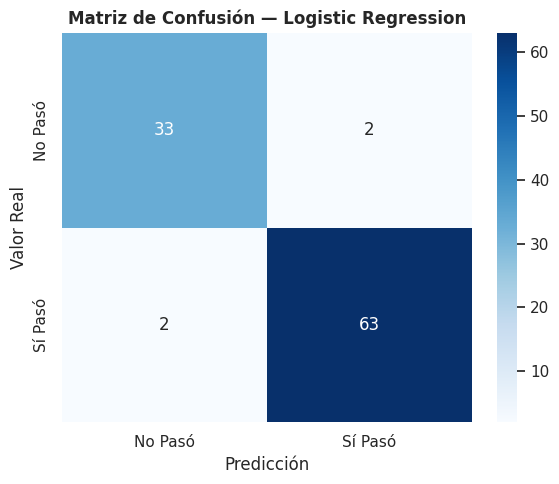

In [72]:
# Matriz de confusión — Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pasó', 'Sí Pasó'],
            yticklabels=['No Pasó', 'Sí Pasó'], ax=ax)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_title('Matriz de Confusión — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

> **¿Cómo leer la matriz de confusión?**
>
> | | Pred: No | Pred: Sí |
> |---|---|---|
> | **Real: No** | Verdadero Negativo (TN) | Falso Positivo (FP) |
> | **Real: Sí** | Falso Negativo (FN) | Verdadero Positivo (TP) |
>
> - **Precision** = TP / (TP + FP): de los que predije "Sí pasó", ¿cuántos lo eran en realidad?  
> - **Recall** = TP / (TP + FN): de los que *realmente* pasaron, ¿cuántos capturé?  
> - **F1** = media armónica de Precision y Recall → equilibra ambas métricas  
> - **AUC-ROC**: capacidad del modelo para distinguir entre clases (1.0 = perfecto, 0.5 = aleatorio)


Intepretación de la matriz de confunción
El AUC se muy cercano a 1 con valor de 0.996 s un valor casi perfecto, lo que sugiere que el modelo es muy bueno diferenciando entre las clases 'No pasó' y 'Sí pasó'. Un valor de 1.0 sería una clasificación perfecta.
Claramente se puede apreciar en la matriz de confusión que predice bien los que sí pasaron y los que no.

### 2.2 Decision Tree (Árbol de Decisión)


**¿Cómo funciona?**

Un árbol de decisión divide el espacio de features mediante **reglas if-then** aprendidas de los datos. En cada nodo elige la variable y el umbral que más reduce la **impureza** (Gini o Entropía).

**Ventajas:**
- Altamente interpretable (se puede visualizar)
- No requiere escalado
- Captura relaciones no lineales

**Desventaja principal: sobreajuste (overfitting)**  
Un árbol sin restricciones memoriza el conjunto de entrenamiento. El hiperparámetro `max_depth` es el control más importante.


In [73]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Árbol sin restricción de profundidad (para ver el efecto del overfitting)
dt_sin_poda = DecisionTreeClassifier(random_state=42)
dt_sin_poda.fit(X_train_c_sc, y_train_c)

# Árbol con profundidad controlada
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=42)
dt.fit(X_train_c_sc, y_train_c)

# Comparación train vs test para detectar overfitting
print('Efecto del control de profundidad en overfitting:')
print()
print(f'{'Modelo':<25} {'Accuracy Train':>16} {'Accuracy Test':>15}')
print('-' * 58)

for nombre, modelo in [('Sin poda (sin límite)', dt_sin_poda),
                        ('Con poda (max_depth=6)', dt)]:
    acc_train = accuracy_score(y_train_c, modelo.predict(X_train_c_sc))
    acc_test  = accuracy_score(y_test_c,  modelo.predict(X_test_c_sc))
    gap = acc_train - acc_test
    print(f'{nombre:<25} {acc_train:>16.4f} {acc_test:>15.4f}  (gap: {gap:+.4f})')

print()
print('→ Un gap grande (train >> test) indica SOBREAJUSTE.')

Efecto del control de profundidad en overfitting:

Modelo                      Accuracy Train   Accuracy Test
----------------------------------------------------------
Sin poda (sin límite)               1.0000          1.0000  (gap: +0.0000)
Con poda (max_depth=6)              1.0000          1.0000  (gap: +0.0000)

→ Un gap grande (train >> test) indica SOBREAJUSTE.


In [74]:
# Métricas completas del árbol podado
y_pred_dt = dt.predict(X_test_c_sc)
y_prob_dt = dt.predict_proba(X_test_c_sc)[:, 1]

print('='*50)
print('  DECISION TREE (max_depth=6) — Resultados en Test')
print('='*50)
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_dt):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_dt):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_dt):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_dt):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_dt):.4f}')

  DECISION TREE (max_depth=6) — Resultados en Test
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  AUC-ROC   : 1.0000


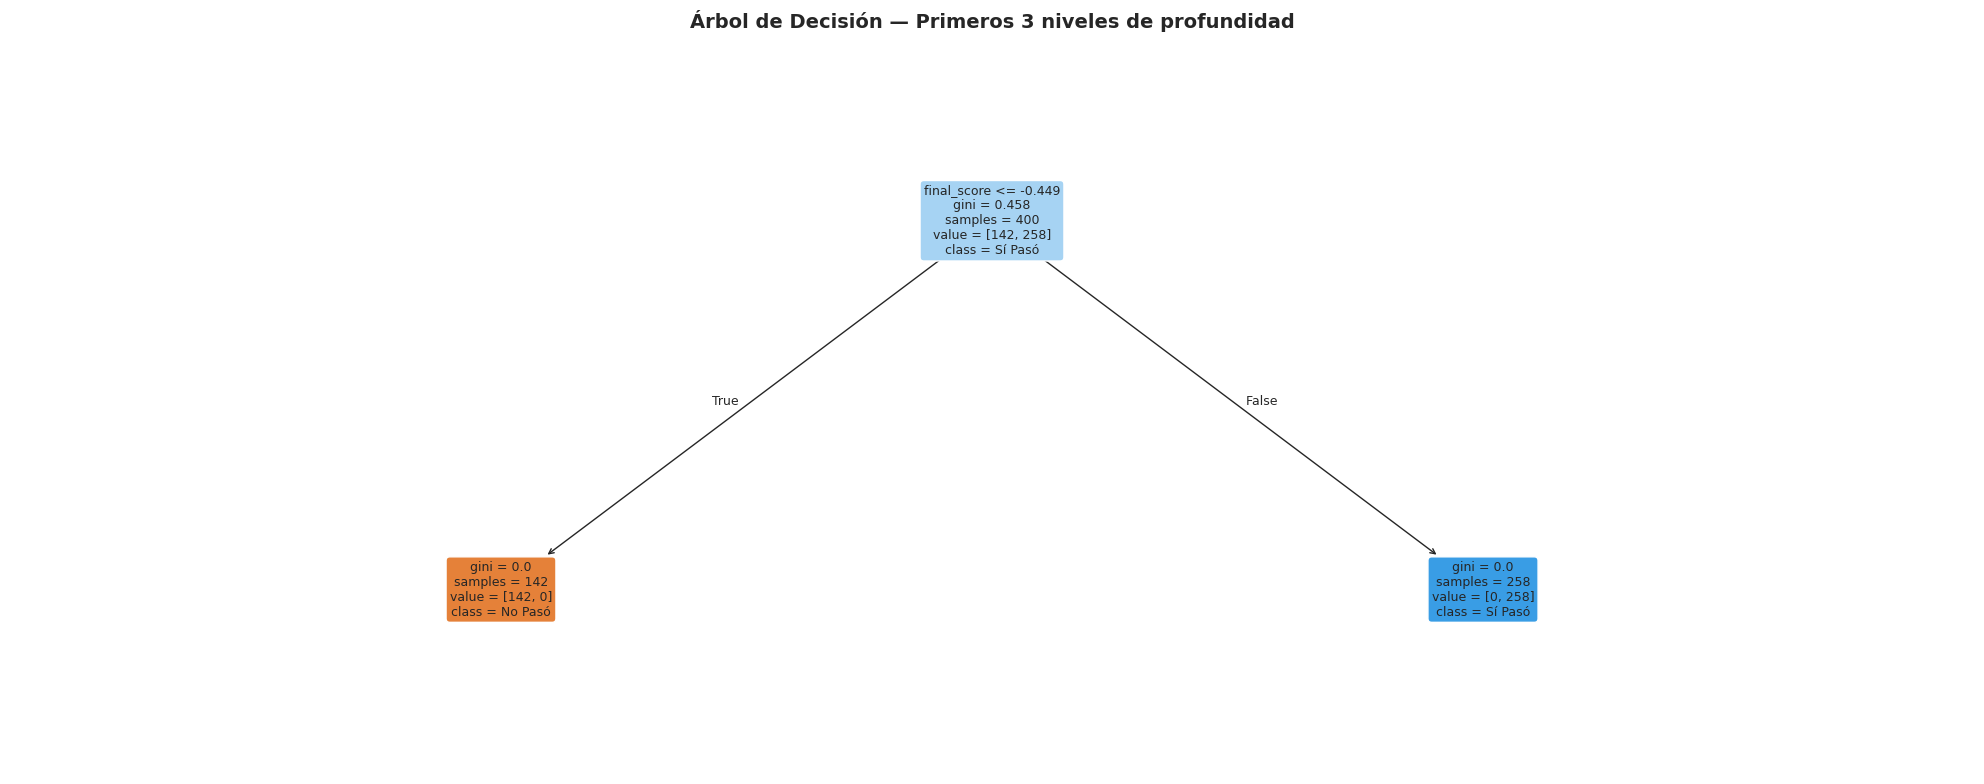

In [76]:
# Visualización del árbol (primeros 3 niveles)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3,
          feature_names=features_clf,
          class_names=['No Pasó', 'Sí Pasó'],
          filled=True, rounded=True,
          fontsize=9, ax=ax)
ax.set_title('Árbol de Decisión — Primeros 3 niveles de profundidad',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Support Vector Machine (SVM)

**Idea central:**

SVM busca el **hiperplano** que maximiza el margen entre las clases. Los puntos más cercanos al hiperplano se llaman **vectores de soporte**.

Con el **kernel trick** (por ejemplo, `rbf`), SVM puede capturar fronteras de decisión no lineales proyectando los datos a espacios de mayor dimensión.

**¿Cuándo usar SVM?**
- Cuando el número de features es alto en relación a las muestras
- Cuando se necesita una frontera de decisión clara
- **Desventaja:** lento en datasets grandes; sensible a la escala (ya escalamos )

>  **SVM es computacionalmente costoso** con datasets grandes. Usaremos una muestra del 20% del conjunto de entrenamiento para este ejemplo.


In [77]:
from sklearn.svm import SVC

# Muestra para SVM (evitar tiempo de cómputo excesivo con >100k muestras)
sample_idx = np.random.RandomState(42).choice(len(X_train_c_sc),
                                               size=int(len(X_train_c_sc)*0.20),
                                               replace=False)
X_svm_train = X_train_c_sc[sample_idx]
y_svm_train = y_train_c.iloc[sample_idx]

svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=42)
svm.fit(X_svm_train, y_svm_train)

y_pred_svm = svm.predict(X_test_c_sc)
y_prob_svm = svm.predict_proba(X_test_c_sc)[:, 1]

print('='*55)
print('  SVM (kernel=rbf, muestra 20%) — Resultados en Test')
print('='*55)
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_svm):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_svm):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_svm):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_svm):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_svm):.4f}')
print()
print(f'  (Entrenado con {len(X_svm_train):,} muestras de {len(X_train_c_sc):,})')

  SVM (kernel=rbf, muestra 20%) — Resultados en Test
  Accuracy  : 0.9100
  Precision : 0.9375
  Recall    : 0.9231
  F1-Score  : 0.9302
  AUC-ROC   : 0.9758

  (Entrenado con 80 muestras de 400)


### 2.4 Comparación de Modelos — Clasificación y Regression


In [79]:
# ── Tabla comparativa de métricas ──────────────────────────────────────────────
resultados_clf = {
    'Logistic Regression': {
        'pred': y_pred_lr, 'prob': y_prob_lr},
    'Decision Tree (d=6)': {
        'pred': y_pred_dt, 'prob': y_prob_dt},
    'SVM (rbf, 20%)': {
        'pred': y_pred_svm, 'prob': y_prob_svm},
}

filas = []
for nombre, data in resultados_clf.items():
    filas.append({
        'Modelo': nombre,
        'Accuracy' : accuracy_score(y_test_c, data['pred']),
        'Precision': precision_score(y_test_c, data['pred']),
        'Recall'   : recall_score(y_test_c, data['pred']),
        'F1-Score' : f1_score(y_test_c, data['pred']),
        'AUC-ROC'  : roc_auc_score(y_test_c, data['prob'])
    })

df_comp = pd.DataFrame(filas).set_index('Modelo')
print('=== Comparación de Modelos de Clasificación ===')
print(df_comp.round(4).to_string())
print()
print(f'   Mejor F1-Score : {df_comp["F1-Score"].idxmax()}')
print(f'   Mejor AUC-ROC  : {df_comp["AUC-ROC"].idxmax()}')

=== Comparación de Modelos de Clasificación ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                             
Logistic Regression    0.9600     0.9692  0.9692    0.9692   0.9960
Decision Tree (d=6)    1.0000     1.0000  1.0000    1.0000   1.0000
SVM (rbf, 20%)         0.9100     0.9375  0.9231    0.9302   0.9758

   Mejor F1-Score : Decision Tree (d=6)
   Mejor AUC-ROC  : Decision Tree (d=6)


Intepretación de los 3 modelos seleccionados

Para esta interpretación se seleccionó 3 modelo de clasificación: Regresión Logística, Árboles de Decisión y Support Vector Machine (SVM) para predicir si los estudiante pasaron o no.

De lo que se pudo observar de la revisión y el ejercicio:


*   Decision Tree (Profundidad 6): Al alcanzar el máximo en Accuracy, F1-Score y AUC-ROC, es el ganador absoluto pero puede estar demasiado ajustado a los datos de entrenamiento.
*   Logistic Regression: Presenta un desempeño excelente y equilibrado (0.96). Su AUC-ROC de 0.9960 indica una capacidad casi perfecta para distinguir entre clases, siendo un modelo muy robusto y confiable.
*   SVM (rbf, 20%): Es el modelo con menor rendimiento de los tres, aunque sigue siendo alto (0.91 de Accuracy). Su F1-Score de 0.93 muestra que todavía maneja bien el balance entre precisión y sensibilidad.

Con estos resultados tomaríamos el modelo de regresión logístico y como segunda opción el SVM que maneja bien el balance entre precisión y sensibilidad




---
## 3. Problema de Regresión: Predicción de la Puntuación Fnal

**Variable objetivo:** `final_score` (Puntuación final)  
**Tipo:** Regresión (variable continua)

### 3.1 Métricas de Regresión

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **MAE** | mean(|y - ŷ|) | Error promedio en la misma unidad que y |
| **MSE** | mean((y - ŷ)²) | Penaliza errores grandes más que MAE |
| **RMSE** | √MSE | Interpretable en la misma unidad que y |
| **R²** | 1 - SS_res/SS_tot | % de varianza explicada (1 = perfecto, 0 = media) |

Un R² de 0.85 significa que el modelo explica el 85% de la variabilidad de la puntuación.



### 3.2 Regresión Lineal — Línea base

In [90]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metricas_regresion(nombre, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_real, y_pred)
    print(f'=== {nombre} ===')
    print(f'  MAE  : ${mae:>12,.2f}')
    print(f'  MSE  : ${mse:>12,.2f}')
    print(f'  RMSE : ${rmse:>12,.2f}')
    print(f'  R²   : {r2:>13.4f}')
    print()
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

resultados_reg = []

# Regresión Lineal
lr_reg = LinearRegression()
lr_reg.fit(X_train_r_sc, y_train_r)
y_pred_lr_reg = lr_reg.predict(X_test_r_sc)
resultados_reg.append(metricas_regresion('Regresión Lineal', y_test_r, y_pred_lr_reg))

=== Regresión Lineal ===
  MAE  : $        6.28
  MSE  : $       53.92
  RMSE : $        7.34
  R²   :        0.7516



### 3.3 Ridge Regression

Ridge agrega un término de **regularización L2** que penaliza coeficientes grandes:

`Función de costo = MSE + λ · Σ(βᵢ²)`

El hiperparámetro `alpha` (= λ) controla la fuerza de la regularización. Es útil cuando hay **multicolinealidad** entre features (como en nuestro caso, donde BasePay y TotalPayBenefits estaban muy correlacionados).


In [91]:
# Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_r_sc, y_train_r)
y_pred_ridge = ridge.predict(X_test_r_sc)
resultados_reg.append(metricas_regresion('Ridge (alpha=10)', y_test_r, y_pred_ridge))

=== Ridge (alpha=10) ===
  MAE  : $        6.27
  MSE  : $       54.18
  RMSE : $        7.36
  R²   :        0.7504



### 3.3 Decision Tree Regressor


In [92]:
# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=8, min_samples_leaf=30, random_state=42)
dt_reg.fit(X_train_r_sc, y_train_r)
y_pred_dt_reg = dt_reg.predict(X_test_r_sc)
resultados_reg.append(metricas_regresion('Decision Tree Regressor (d=8)', y_test_r, y_pred_dt_reg))


=== Decision Tree Regressor (d=8) ===
  MAE  : $        7.13
  MSE  : $       75.12
  RMSE : $        8.67
  R²   :        0.6539



### 3.4 Comparativo de los modelos de regresión


In [93]:
# ── Tabla comparativa — Regresión ──────────────────────────────────────────────
df_reg = pd.DataFrame(resultados_reg).set_index('Modelo')
print('=== Comparación de Modelos de Regresión ===')
print(df_reg.round(4).to_string())
print()
print(f'   Mejor R²   : {df_reg["R²"].idxmax()}')
print(f'   Menor RMSE : {df_reg["RMSE"].idxmin()}')

=== Comparación de Modelos de Regresión ===
                                 MAE   RMSE     R²
Modelo                                            
Regresión Lineal              6.2759 7.3432 0.7516
Ridge (alpha=10)              6.2729 7.3605 0.7504
Decision Tree Regressor (d=8) 7.1342 8.6673 0.6539

   Mejor R²   : Regresión Lineal
   Menor RMSE : Regresión Lineal


##Interpretación de la comparativa de los modelos de regresión

La Regresión Lineal es el mejor modelo en este caso. Aunque la diferencia con Ridge es mínima, la Regresión Lineal obtiene el mejor \(R^{2}\) (0.7516) y el menor RMSE (7.3432). Esto indica que es el modelo que mejor explica la variabilidad de los datos y el que comete errores de mayor magnitud con menos frecuencia

###Interpretación de las Métricas

*   \(R^{2}\) (Coeficiente de Determinación): El valor de 0.7516 significa que el modelo de Regresión Lineal logra explicar aproximadamente el 75% de la varianza de tus datos. Es un rendimiento sólido para la mayoría de los contextos prácticos.
*   MAE (Error Medio Absoluto): La Regresión Lineal y Ridge están prácticamente empatados (~6.27). Esto significa que, en promedio, las predicciones del modelo fallan por unas 6.27 unidades respecto al valor real.
*   RMSE (Raíz del Error Cuadrático Medio): Es ligeramente superior al MAE (7.34). Como el RMSE penaliza más los errores grandes, su cercanía al MAE sugiere que el modelo no tiene "outliers" o errores catastróficos muy frecuentes.

###Comparativa entre Modelos

*   Regresión Lineal vs. Ridge: El hecho de que Ridge (con alpha=10) tenga un desempeño casi idéntico (e incluso un MAE ligeramente mejor por milésimas) indica que la penalización de Ridge no está aportando una mejora significativa. El modelo no parece sufrir de multicolinealidad severa.
*   Decision Tree Regressor (d=8): Es el peor modelo de la lista. Tiene el \(R^{2}\) más bajo (0.65) y los errores más altos. Esto sugiere que una estructura de árbol de profundidad 8 no captura la relación de los datos tan bien como una línea recta (modelo lineal), o bien está perdiendo precisión en los rangos numéricos.

